<a href="https://colab.research.google.com/github/kshirsagar-mahesh/CSL701-Roll_No_Machine-Learning-Lab/blob/main/ML%20EXP04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a **Logistic Regression** model to classify credit card transactions as **fraudulent or legitimate**.




Mahesh Sakharam Kshirsagar
BECSE 27
CS 02

## Objectives

1. To understand the mathematical foundations of **Logistic Regression** and the **Sigmoid Function**.
2. To understand and handle **class imbalance** in credit card fraud datasets.
3. To implement **Gradient Descent** for optimizing Logistic Regression parameters.
4. To evaluate the model using **Confusion Matrix, Precision, Recall, F1-Score, ROC Curve, and AUC**.
5. To understand the importance of **Recall and False Negative Rate** in fraud detection.


## Relevant Theory

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for **binary classification**. In this experiment, it is used to classify credit card transactions into two classes:

- **0 $\rightarrow$ Legitimate transaction**
- **1 $\rightarrow$ Fraudulent transaction**

The model first calculates a linear combination of input features:

$$
z = w^T X + b
$$

where:

- $w$ = weight vector
- $X$ = input feature vector
- $b$ = bias/intercept
- $z$ = linear predictor

---

### Sigmoid Function

The Sigmoid Function converts the value of $z$ into a probability between 0 and 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The predicted probability that a transaction is fraudulent is:

$$
P(y=1|X) = \sigma(w^T X + b)
$$

The predicted class can be obtained using a threshold:

$$
\hat{y} =
\begin{cases}
1, & \text{if } P(y=1|X) \geq 0.5 \\
0, & \text{if } P(y=1|X) < 0.5
\end{cases}
$$

---
## Cost Function

Logistic Regression uses the **Binary Cross-Entropy Loss** or **Log Loss**.

The cost function is:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

- $m$ = number of training examples
- $y_i$ = actual class label
- $\hat{y}_i$ = predicted probability

The objective of training is to find values of $w$ and $b$ that minimize the cost function.

---

## Gradient Descent

Gradient Descent is used to optimize the parameters of the Logistic Regression model.

The weights are updated using:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

The bias is updated using:

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

For Logistic Regression, the gradient of the cost function with respect to the weights can be expressed as:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

The gradient with respect to the bias is:

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
$$

Therefore, the parameter updates become:

$$
w := w - \alpha
\left[
\frac{1}{m}X^T(\hat{y}-y)
\right]
$$

$$
b := b - \alpha
\left[
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
\right]
$$

---

## Class Imbalance

Credit card fraud datasets are generally highly imbalanced because legitimate transactions significantly outnumber fraudulent transactions.

For example, the dataset may contain a very large number of legitimate transactions and only a small number of fraudulent transactions.

A model that predicts most transactions as legitimate may achieve high accuracy but perform poorly at detecting fraud.

Therefore, techniques such as:

- Random Undersampling
- Oversampling
- Class Weighting

can be used to handle class imbalance.

---

## Evaluation Metrics

### Confusion Matrix

The confusion matrix consists of four components:

- **True Positive (TP):** Fraudulent transaction correctly identified as fraud.
- **True Negative (TN):** Legitimate transaction correctly identified as legitimate.
- **False Positive (FP):** Legitimate transaction incorrectly identified as fraud.
- **False Negative (FN):** Fraudulent transaction incorrectly identified as legitimate.

---

### Accuracy

Accuracy measures the proportion of correctly classified transactions:

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

However, accuracy alone is not sufficient for highly imbalanced fraud detection datasets.

---

### Precision

Precision indicates the proportion of transactions predicted as fraudulent that are actually fraudulent:

$$
Precision =
\frac{TP}
{TP+FP}
$$

A high Precision means that the model produces fewer false fraud alerts.

---

### Recall

Recall measures the proportion of actual fraudulent transactions correctly detected:

$$
Recall =
\frac{TP}
{TP+FN}
$$

Recall is particularly important in fraud detection because a **False Negative** represents a fraudulent transaction that was not detected.

---

### F1-Score

F1-Score is the harmonic mean of Precision and Recall:

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

---

## ROC Curve

The Receiver Operating Characteristic (ROC) curve represents the relationship between the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** at different classification thresholds.

The True Positive Rate is:

$$
TPR =
\frac{TP}
{TP+FN}
$$

The False Positive Rate is:

$$
FPR =
\frac{FP}
{FP+TN}
$$

The ROC curve helps determine how well the model separates fraudulent transactions from legitimate transactions.

---

## *Area Under the Curve (AUC)*

The **Area Under the ROC Curve (AUC)** summarizes the performance of the classifier across different classification thresholds.

An AUC value close to:

$$
AUC = 1
$$

indicates excellent discrimination, while:

$$
AUC = 0.5
$$

indicates performance approximately equivalent to random classification.

---

### Dataset Information

The Credit Card Fraud Dataset contains transaction-related features such as transaction amount, distance from home, purchase-price-related ratios, and transaction characteristics.

The target variable is fraud:


0 → Legitimate transaction

1 → Fraudulent transaction

---

## Task 1: Environment Setup and Dataset Acquisition

Use dataset for this experiment [Credit Card Fraud Dataset](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)

Import the required Python libraries such as **NumPy, Pandas, Matplotlib, and Scikit-learn**.

Load the **Credit Card Fraud Dataset** into a Pandas DataFrame.

Display the following information:

* First five records of the dataset.
* Shape of the dataset.
* Column names.
* Data types of all columns.
* Descriptive statistics of numerical features.

Identify the **feature variables** and the **target variable** `fraud`.

The target variable is defined as:

$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

fraud =

* 0 -> Legitimate transaction

* 1 -> Fraudulent transaction


The objective of this task is to understand the structure of the dataset and identify the input features and target variable required for building the Logistic Regression model.

Identify the feature variables and the target variable fraud.

In [ ]:
# ============================================================
# TASK 1: ENVIRONMENT SETUP AND DATASET ACQUISITION
# Credit Card Fraud Dataset
# ============================================================

# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# Step 2: Load the dataset
# ------------------------------------------------------------

# FOR GOOGLE COLAB:
from google.colab import files

print("Please upload the Credit Card Fraud CSV dataset:")
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Read CSV file
df = pd.read_csv(filename)

# ------------------------------------------------------------
# Step 3: Display first five records
# ------------------------------------------------------------

print("\n========== FIRST FIVE RECORDS ==========")
print(df.head())

# ------------------------------------------------------------
# Step 4: Display shape of dataset
# ------------------------------------------------------------

print("\n========== DATASET SHAPE ==========")
print("Number of rows and columns:", df.shape)

# ------------------------------------------------------------
# Step 5: Display column names
# ------------------------------------------------------------

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

# ------------------------------------------------------------
# Step 6: Display data types
# ------------------------------------------------------------

print("\n========== DATA TYPES ==========")
print(df.dtypes)

# ------------------------------------------------------------
# Step 7: Display descriptive statistics
# ------------------------------------------------------------

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())

# ------------------------------------------------------------
# Step 8: Check whether 'fraud' column exists
# ------------------------------------------------------------

if 'fraud' in df.columns:

    # Target variable
    target = 'fraud'

    # Feature variables
    features = df.drop(columns=[target])

    print("\n========== TARGET VARIABLE ==========")
    print("Target variable:", target)

    print("\n========== FEATURE VARIABLES ==========")
    print(features.columns.tolist())

    # --------------------------------------------------------
    # Step 9: Display target class information
    # --------------------------------------------------------

    print("\n========== FRAUD CLASS COUNTS ==========")
    print(df[target].value_counts())

    print("\n========== FRAUD CLASS PERCENTAGE ==========")
    class_percentage = df[target].value_counts(normalize=True) * 100
    print(class_percentage)

    # --------------------------------------------------------
    # Step 10: Display class meaning
    # --------------------------------------------------------

    print("\n========== TARGET CLASS MEANING ==========")
    print("0 -> Legitimate transaction")
    print("1 -> Fraudulent transaction")

else:
    print("\nERROR: 'fraud' column was not found in the dataset.")
    print("Available columns are:")
    print(df.columns.tolist())

Please upload the Credit Card Fraud CSV dataset:


Saving card_transdata.csv to card_transdata.csv

========== FIRST FIVE RECORDS ==========
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3       

## Task 2: Perform Exploratory Data Analysis

Perform **Exploratory Data Analysis (EDA)** to understand the structure, distribution, and characteristics of the Credit Card Fraud Dataset.

Calculate and display the following:

* Number of **legitimate transactions**.
* Number of **fraudulent transactions**.
* Percentage of legitimate transactions.
* Percentage of fraudulent transactions.
* Distribution of numerical features.

The percentage of each class can be calculated using:
$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

Plot the **class distribution** using a suitable visualization such as a bar chart.

Analyze the class distribution and explain the problem of **classification imbalance** in credit card fraud detection.

A dataset is considered highly imbalanced when the number of legitimate transactions is significantly greater than the number of fraudulent transactions. Therefore, accuracy alone may not be sufficient to evaluate the performance of the fraud detection model.


========== DATASET INFORMATION ==========
Number of rows: 1000000
Number of columns: 8

========== TRANSACTION COUNTS ==========
Legitimate transactions: 912597
Fraudulent transactions: 87403
Total transactions: 1000000

========== TRANSACTION PERCENTAGES ==========
Percentage of legitimate transactions: 91.26 %
Percentage of fraudulent transactions: 8.74 %

========== CLASS DISTRIBUTION SUMMARY ==========
  Transaction Type   Count  Percentage
0       Legitimate  912597     91.2597
1       Fraudulent   87403      8.7403

========== NUMERICAL FEATURES ==========
Numerical columns:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

Descriptive statistics:
       distance_from_home  distance_from_last_transaction  \
count      1000000.000000                  1000000.000000   
mean            26.628792                        5.036519   
std             65.390784            

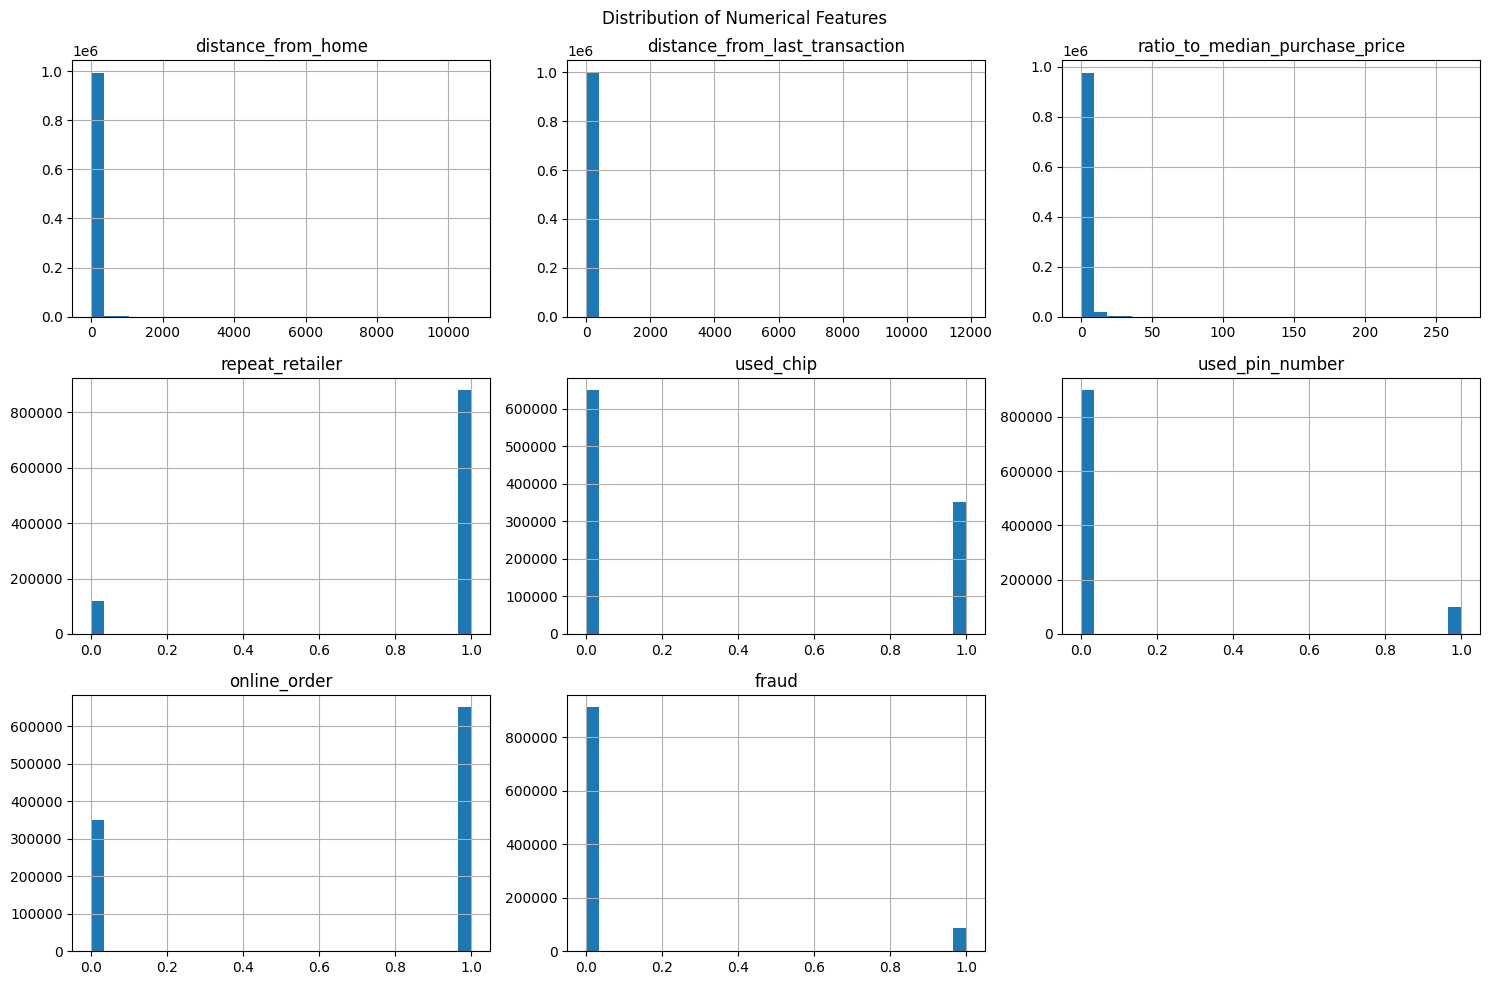

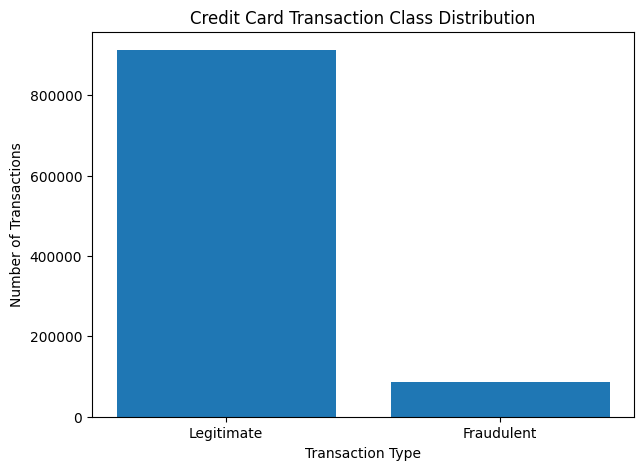


========== CLASS IMBALANCE ANALYSIS ==========
The dataset is imbalanced.
Legitimate transactions are much greater than fraudulent transactions.
Imbalance ratio: 10.44 : 1

Accuracy alone may not be sufficient for evaluating
a credit card fraud detection model.
Precision, Recall, F1-score and Confusion Matrix
should also be considered.


In [ ]:
# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# Credit Card Fraud Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Check the dataset
# ------------------------------------------------------------

print("========== DATASET INFORMATION ==========")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# ------------------------------------------------------------
# STEP 2: Count legitimate and fraudulent transactions
# ------------------------------------------------------------

legitimate_count = (df['fraud'] == 0).sum()
fraud_count = (df['fraud'] == 1).sum()

total_transactions = len(df)

print("\n========== TRANSACTION COUNTS ==========")
print("Legitimate transactions:", legitimate_count)
print("Fraudulent transactions:", fraud_count)
print("Total transactions:", total_transactions)

# ------------------------------------------------------------
# STEP 3: Calculate percentages
# ------------------------------------------------------------

legitimate_percentage = (legitimate_count / total_transactions) * 100
fraud_percentage = (fraud_count / total_transactions) * 100

print("\n========== TRANSACTION PERCENTAGES ==========")
print("Percentage of legitimate transactions:",
      round(legitimate_percentage, 2), "%")

print("Percentage of fraudulent transactions:",
      round(fraud_percentage, 2), "%")

# ------------------------------------------------------------
# STEP 4: Create a summary table
# ------------------------------------------------------------

class_summary = pd.DataFrame({
    'Transaction Type': ['Legitimate', 'Fraudulent'],
    'Count': [legitimate_count, fraud_count],
    'Percentage': [legitimate_percentage, fraud_percentage]
})

print("\n========== CLASS DISTRIBUTION SUMMARY ==========")
print(class_summary)

# ------------------------------------------------------------
# STEP 5: Distribution of numerical features
# ------------------------------------------------------------

print("\n========== NUMERICAL FEATURES ==========")

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

print("\nDescriptive statistics:")
print(df[numerical_columns].describe())

# ------------------------------------------------------------
# STEP 6: Plot distribution of numerical features
# ------------------------------------------------------------

df[numerical_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 7: Plot class distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

classes = ['Legitimate', 'Fraudulent']
counts = [legitimate_count, fraud_count]

plt.bar(classes, counts)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Credit Card Transaction Class Distribution")

plt.show()

# ------------------------------------------------------------
# STEP 8: Print class imbalance analysis
# ------------------------------------------------------------

print("\n========== CLASS IMBALANCE ANALYSIS ==========")

if legitimate_count > fraud_count:
    imbalance_ratio = legitimate_count / fraud_count

    print("The dataset is imbalanced.")
    print("Legitimate transactions are much greater than fraudulent transactions.")
    print("Imbalance ratio:",
          round(imbalance_ratio, 2),
          ": 1")

    print("\nAccuracy alone may not be sufficient for evaluating")
    print("a credit card fraud detection model.")

    print("Precision, Recall, F1-score and Confusion Matrix")
    print("should also be considered.")
else:
    print("The dataset does not show a majority of legitimate transactions.")

## Task 3: Data Preprocessing

Check the dataset for the following:

* Missing values.
* Duplicate records.
* Categorical variables.
* Numerical variables.

Identify the number of missing values in each column and handle them using suitable techniques such as **removal or imputation**.

Identify categorical variables and convert them into numerical form using appropriate **encoding techniques**.

For example, categorical variables can be converted into numerical values using **One-Hot Encoding**.

Also, identify the numerical features that will be used for building the Logistic Regression model.

The objective of this task is to prepare a clean and suitable dataset for further processing, feature scaling, model training, and evaluation.


In [ ]:
# ============================================================
# TASK 3: DATA PREPROCESSING
# Credit Card Fraud Dataset
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# STEP 1: Check missing values
# ------------------------------------------------------------

print("========== MISSING VALUES ==========")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:",
      missing_values.sum())

# ------------------------------------------------------------
# STEP 2: Handle missing values
# ------------------------------------------------------------

# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Remove target variable from feature lists
if 'fraud' in numerical_columns:
    numerical_columns.remove('fraud')

if 'fraud' in categorical_columns:
    categorical_columns.remove('fraud')

# Fill numerical missing values with median
for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("\n========== MISSING VALUES AFTER HANDLING ==========")
print(df.isnull().sum())

# ------------------------------------------------------------
# STEP 3: Check duplicate records
# ------------------------------------------------------------

print("\n========== DUPLICATE RECORDS ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

# Remove duplicate records
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

print("Dataset shape after removing duplicates:", df.shape)

# ------------------------------------------------------------
# STEP 4: Identify categorical variables
# ------------------------------------------------------------

print("\n========== CATEGORICAL VARIABLES ==========")

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(categorical_columns)

# ------------------------------------------------------------
# STEP 5: Identify numerical variables
# ------------------------------------------------------------

print("\n========== NUMERICAL VARIABLES ==========")

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target variable
if 'fraud' in numerical_columns:
    numerical_columns.remove('fraud')

print(numerical_columns)

# ------------------------------------------------------------
# STEP 6: Separate features and target
# ------------------------------------------------------------

X = df.drop(columns=['fraud'])
y = df['fraud']

print("\n========== FEATURES AND TARGET ==========")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget variable:")
print("fraud")

# ------------------------------------------------------------
# STEP 7: One-Hot Encoding
# ------------------------------------------------------------

if len(categorical_columns) > 0:

    print("\n========== APPLYING ONE-HOT ENCODING ==========")

    X = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True
    )

    print("Categorical variables encoded successfully.")

else:
    print("\nNo categorical variables found.")

# ------------------------------------------------------------
# STEP 8: Convert Boolean columns to integers
# ------------------------------------------------------------

X = X.astype(float)

# ------------------------------------------------------------
# STEP 9: Display final feature variables
# ------------------------------------------------------------

print("\n========== FINAL FEATURE VARIABLES ==========")

print(X.columns.tolist())

print("\nTotal number of features:", X.shape[1])

# ------------------------------------------------------------
# STEP 10: Verify all features are numerical
# ------------------------------------------------------------

print("\n========== FINAL DATA TYPES ==========")

print(X.dtypes)

# ------------------------------------------------------------
# STEP 11: Verify missing values
# ------------------------------------------------------------

print("\n========== FINAL MISSING VALUE CHECK ==========")

print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

# ------------------------------------------------------------
# STEP 12: Display final dataset
# ------------------------------------------------------------

print("\n========== FINAL FEATURE DATA ==========")

print(X.head())

print("\n========== TARGET DATA ==========")

print(y.head())

# ------------------------------------------------------------
# STEP 13: Final dataset information
# ------------------------------------------------------------

print("\n========== FINAL DATASET INFORMATION ==========")

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nData preprocessing completed successfully.")

========== MISSING VALUES ==========
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Total missing values: 0

========== MISSING VALUES AFTER HANDLING ==========
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

========== DUPLICATE RECORDS ==========
Number of duplicate records: 0
No duplicate records found.
Dataset shape after removing duplicates: (1000000, 8)

========== CATEGORICAL VARIABLES ==========
[]

========== NUMERICAL VARIABLES ==========
['distance_from_home', 'distance_from_

## Task 4: Feature Scaling and Class Imbalance Handling

Standardize the numerical features using **Standardization** so that they have approximately zero mean and unit variance.

The standardized value of a feature is calculated as:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

* (x) = original feature value
* (\mu) = mean of the feature
* (\sigma) = standard deviation of the feature
* (z) = standardized feature value

Handle the **class imbalance** in the dataset using a suitable technique such as:

* Random Undersampling
* Oversampling
* Class Weighting

Display the class distribution **before and after** applying the selected class-imbalance handling technique.

Compare the number of legitimate and fraudulent transactions before and after balancing.

The objective of this task is to ensure that the features are on a comparable scale and that the Logistic Regression model does not become biased toward the majority class.


========== CLASS DISTRIBUTION BEFORE BALANCING ==========
Legitimate transactions (0): 912597
Fraudulent transactions (1): 87403

Percentage distribution:
fraud
0.0    91.2597
1.0     8.7403
Name: proportion, dtype: float64

========== NUMERICAL FEATURES ==========
Number of numerical features: 7
Numerical features:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

========== AFTER STANDARDIZATION ==========
   distance_from_home  distance_from_last_transaction  \
0            0.477882                       -0.182849   
1           -0.241607                       -0.188094   
2           -0.329369                       -0.163733   
3           -0.372854                        0.021806   
4            0.268572                       -0.172968   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        0.043491         0.366584   1.361576   
1     

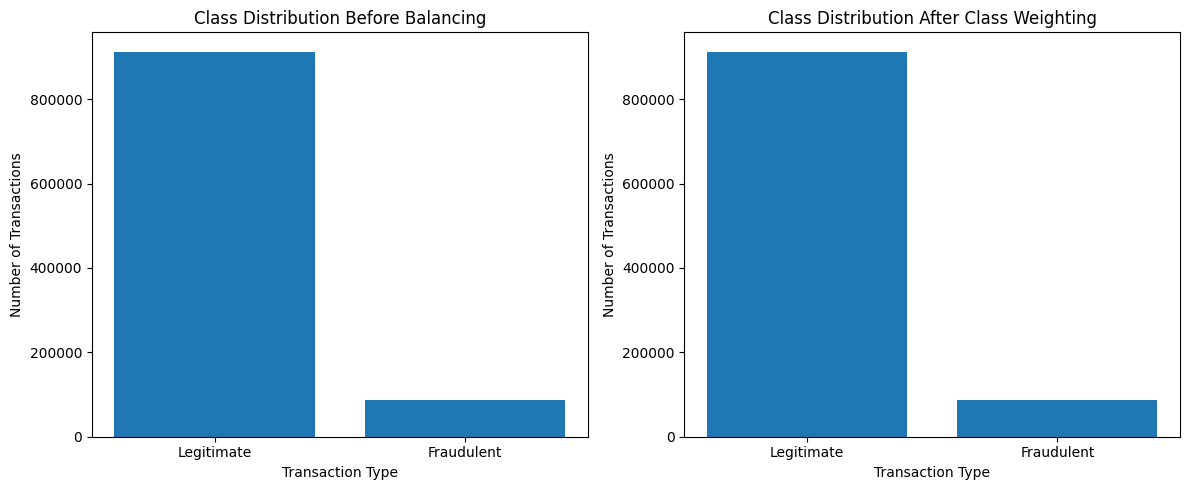


========== TASK 4 COMPLETED ==========
Feature scaling: Standardization
Class imbalance technique: Class Weighting

X_scaled shape: (1000000, 7)
y shape: (1000000,)


In [ ]:
# ============================================================
# TASK 4: FEATURE SCALING AND CLASS IMBALANCE HANDLING
# Credit Card Fraud Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# STEP 1: Check class distribution BEFORE balancing
# ------------------------------------------------------------

print("========== CLASS DISTRIBUTION BEFORE BALANCING ==========")

before_counts = y.value_counts().sort_index()

print("Legitimate transactions (0):", before_counts.get(0, 0))
print("Fraudulent transactions (1):", before_counts.get(1, 0))

print("\nPercentage distribution:")
print((y.value_counts(normalize=True) * 100).sort_index())

# ------------------------------------------------------------
# STEP 2: Identify numerical features
# ------------------------------------------------------------

print("\n========== NUMERICAL FEATURES ==========")

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

# ------------------------------------------------------------
# STEP 3: Standardize numerical features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = X.copy()

X_scaled[numerical_features] = scaler.fit_transform(
    X[numerical_features]
)

print("\n========== AFTER STANDARDIZATION ==========")

print(X_scaled.head())

# ------------------------------------------------------------
# STEP 4: Check mean and standard deviation
# ------------------------------------------------------------

print("\n========== MEAN AFTER STANDARDIZATION ==========")

print(X_scaled[numerical_features].mean())

print("\n========== STANDARD DEVIATION AFTER STANDARDIZATION ==========")

print(X_scaled[numerical_features].std())

# ------------------------------------------------------------
# STEP 5: Handle class imbalance using Class Weighting
# ------------------------------------------------------------

classes = np.unique(y)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

print("\n========== CLASS WEIGHTS ==========")

print(class_weight_dict)

print("\nWeight for legitimate transactions (0):",
      class_weight_dict[0])

print("Weight for fraudulent transactions (1):",
      class_weight_dict[1])

# ------------------------------------------------------------
# STEP 6: Display class distribution AFTER class weighting
# ------------------------------------------------------------

print("\n========== CLASS DISTRIBUTION AFTER CLASS WEIGHTING ==========")

print("Original number of legitimate transactions:",
      before_counts.get(0, 0))

print("Original number of fraudulent transactions:",
      before_counts.get(1, 0))

print("\nClass weighting does NOT remove or duplicate records.")
print("Therefore, the number of records remains unchanged.")

after_counts = y.value_counts().sort_index()

print("\nLegitimate transactions after weighting:",
      after_counts.get(0, 0))

print("Fraudulent transactions after weighting:",
      after_counts.get(1, 0))

# ------------------------------------------------------------
# STEP 7: Create comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    'Class': ['Legitimate (0)', 'Fraudulent (1)'],
    'Before Balancing': [
        before_counts.get(0, 0),
        before_counts.get(1, 0)
    ],
    'After Balancing': [
        after_counts.get(0, 0),
        after_counts.get(1, 0)
    ]
})

print("\n========== BEFORE AND AFTER COMPARISON ==========")

print(comparison)

# ------------------------------------------------------------
# STEP 8: Plot class distribution BEFORE and AFTER
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before balancing
axes[0].bar(
    ['Legitimate', 'Fraudulent'],
    [before_counts.get(0, 0), before_counts.get(1, 0)]
)

axes[0].set_title("Class Distribution Before Balancing")
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Number of Transactions")

# After class weighting
axes[1].bar(
    ['Legitimate', 'Fraudulent'],
    [after_counts.get(0, 0), after_counts.get(1, 0)]
)

axes[1].set_title("Class Distribution After Class Weighting")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 9: Final information
# ------------------------------------------------------------

print("\n========== TASK 4 COMPLETED ==========")

print("Feature scaling: Standardization")
print("Class imbalance technique: Class Weighting")

print("\nX_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)


## Task 5: Split the Dataset

Divide the preprocessed dataset into three subsets:

* **Training Set -- 60%**
* **Validation Set -- 20%**
* **Test Set -- 20%**

Use **stratified splitting** to maintain a representative proportion of fraudulent and legitimate transactions in each subset.

The dataset should first be divided into training and temporary sets. The temporary set should then be divided equally into validation and test sets.

The objective of this task is to use the training set for model training, the validation set for model evaluation and parameter selection, and the test set for final performance evaluation.


In [ ]:
# ============================================================
# TASK 5: SPLIT THE DATASET
# Credit Card Fraud Dataset
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# STEP 1: Use preprocessed features and target
# ------------------------------------------------------------

# X_scaled = standardized features from Task 4
# y = target variable (fraud)

print("Original dataset shape:")
print("X:", X_scaled.shape)
print("y:", y.shape)

# ------------------------------------------------------------
# STEP 2: First split
# 60% Training
# 40% Temporary
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# STEP 3: Second split
# Temporary 40% -> 20% Validation + 20% Test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ------------------------------------------------------------
# STEP 4: Display shapes
# ------------------------------------------------------------

print("\n========== DATASET SPLIT ==========")

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# ------------------------------------------------------------
# STEP 5: Calculate percentages
# ------------------------------------------------------------

total = len(X_scaled)

train_percentage = (len(X_train) / total) * 100
val_percentage = (len(X_val) / total) * 100
test_percentage = (len(X_test) / total) * 100

print("\n========== SPLIT PERCENTAGES ==========")

print("Training:", round(train_percentage, 2), "%")
print("Validation:", round(val_percentage, 2), "%")
print("Test:", round(test_percentage, 2), "%")

# ------------------------------------------------------------
# STEP 6: Check class distribution in each set
# ------------------------------------------------------------

print("\n========== CLASS DISTRIBUTION ==========")

print("\nTraining Set:")
print(y_train.value_counts())
print("Percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation Set:")
print(y_val.value_counts())
print("Percentage:")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nTest Set:")
print(y_test.value_counts())
print("Percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

# ------------------------------------------------------------
# STEP 7: Verify stratification
# ------------------------------------------------------------

print("\n========== STRATIFICATION CHECK ==========")

original_fraud_percentage = (y.mean() * 100)
train_fraud_percentage = (y_train.mean() * 100)
val_fraud_percentage = (y_val.mean() * 100)
test_fraud_percentage = (y_test.mean() * 100)

print("Original fraud percentage:",
      round(original_fraud_percentage, 2), "%")

print("Training fraud percentage:",
      round(train_fraud_percentage, 2), "%")

print("Validation fraud percentage:",
      round(val_fraud_percentage, 2), "%")

print("Test fraud percentage:",
      round(test_fraud_percentage, 2), "%")

print("\n========== TASK 5 COMPLETED ==========")

Original dataset shape:
X: (1000000, 7)
y: (1000000,)

========== DATASET SPLIT ==========
Training set:
X_train: (600000, 7)
y_train: (600000,)

Validation set:
X_val: (200000, 7)
y_val: (200000,)

Test set:
X_test: (200000, 7)
y_test: (200000,)

========== SPLIT PERCENTAGES ==========
Training: 60.0 %
Validation: 20.0 %
Test: 20.0 %

========== CLASS DISTRIBUTION ==========

Training Set:
fraud
0.0    547558
1.0     52442
Name: count, dtype: int64
Percentage:
fraud
0.0    91.26
1.0     8.74
Name: proportion, dtype: float64

Validation Set:
fraud
0.0    182519
1.0     17481
Name: count, dtype: int64
Percentage:
fraud
0.0    91.26
1.0     8.74
Name: proportion, dtype: float64

Test Set:
fraud
0.0    182520
1.0     17480
Name: count, dtype: int64
Percentage:
fraud
0.0    91.26
1.0     8.74
Name: proportion, dtype: float64

========== STRATIFICATION CHECK ==========
Original fraud percentage: 8.74 %
Training fraud percentage: 8.74 %
Validation fraud percentage: 8.74 %
Test fraud percenta

## Task 6: Implement Sigmoid and Cost Functions

Implement the **Sigmoid Function** used in Logistic Regression.

The Sigmoid Function is defined as:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

The Sigmoid Function converts the output of the linear equation into a probability value between 0 and 1.

Implement the **Binary Cross-Entropy Cost Function**:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

* (m) = number of training samples
* (y_i) = actual class label
* (\hat{y}_i) = predicted probability
* (w) = weight vector
* (b) = bias

Test the Sigmoid Function using suitable sample values.

Calculate the initial cost of the Logistic Regression model using the initialized weights and bias.

The objective of this task is to understand how the Sigmoid Function produces probabilities and how the Binary Cross-Entropy Cost Function measures the error of the Logistic Regression model.


Training feature shape: (600000, 7)
Training target shape: (600000,)

========== SIGMOID FUNCTION TEST ==========
z = -10   sigmoid(z) = 4.5e-05
z = -5   sigmoid(z) = 0.006693
z = -2   sigmoid(z) = 0.119203
z = 0   sigmoid(z) = 0.5
z = 2   sigmoid(z) = 0.880797
z = 5   sigmoid(z) = 0.993307
z = 10   sigmoid(z) = 0.999955


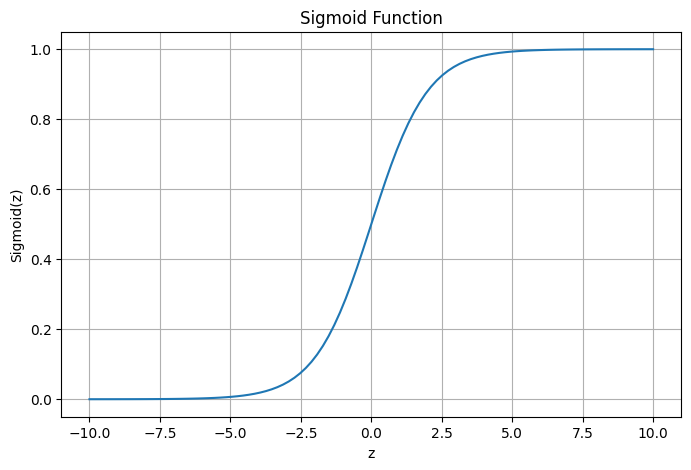


========== INITIAL PARAMETERS ==========
Number of features: 7
Initial weights:
[0. 0. 0. 0. 0. 0. 0.]
Initial bias: 0.0

========== INITIAL PREDICTIONS ==========
First 10 predicted probabilities:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]

========== INITIAL COST ==========
Initial Cost: 0.6931471805599454

========== TASK 6 SUMMARY ==========
Sigmoid function implemented successfully.
Binary Cross-Entropy cost function implemented successfully.
Weights initialized to zero.
Bias initialized to zero.
Initial cost calculated successfully.


In [ ]:
# ============================================================
# TASK 6: IMPLEMENT SIGMOID AND COST FUNCTIONS
# Logistic Regression - Credit Card Fraud Detection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Convert training data to NumPy arrays
# ------------------------------------------------------------

X_train_np = np.asarray(X_train, dtype=float)
y_train_np = np.asarray(y_train, dtype=float)

print("Training feature shape:", X_train_np.shape)
print("Training target shape:", y_train_np.shape)


# ------------------------------------------------------------
# STEP 2: Define Sigmoid Function
# ------------------------------------------------------------

def sigmoid(z):
    """
    Sigmoid function:

            1
    σ(z) = ------
           1 + e^(-z)

    Converts any real number into a value between 0 and 1.
    """

    # Prevent overflow in exponential calculation
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


# ------------------------------------------------------------
# STEP 3: Test Sigmoid Function
# ------------------------------------------------------------

print("\n========== SIGMOID FUNCTION TEST ==========")

sample_values = np.array([-10, -5, -2, 0, 2, 5, 10])

sigmoid_values = sigmoid(sample_values)

for z, result in zip(sample_values, sigmoid_values):
    print("z =", z, "  sigmoid(z) =", round(result, 6))


# ------------------------------------------------------------
# STEP 4: Plot Sigmoid Function
# ------------------------------------------------------------

z_values = np.linspace(-10, 10, 100)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid(z_values))

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")

plt.grid(True)
plt.show()


# ------------------------------------------------------------
# STEP 5: Initialize weights and bias
# ------------------------------------------------------------

number_of_features = X_train_np.shape[1]

# Initialize all weights to zero
w = np.zeros(number_of_features)

# Initialize bias to zero
b = 0.0

print("\n========== INITIAL PARAMETERS ==========")

print("Number of features:", number_of_features)
print("Initial weights:")
print(w)

print("Initial bias:", b)


# ------------------------------------------------------------
# STEP 6: Calculate predicted probabilities
# ------------------------------------------------------------

def predict_probability(X, w, b):
    """
    Calculate predicted probability:

    z = Xw + b
    probability = sigmoid(z)
    """

    z = np.dot(X, w) + b

    return sigmoid(z)


y_pred_initial = predict_probability(
    X_train_np,
    w,
    b
)

print("\n========== INITIAL PREDICTIONS ==========")

print("First 10 predicted probabilities:")
print(y_pred_initial[:10])


# ------------------------------------------------------------
# STEP 7: Implement Binary Cross-Entropy Cost Function
# ------------------------------------------------------------

def compute_cost(X, y, w, b):
    """
    Binary Cross-Entropy Cost:

    J(w,b) = -1/m Σ[
             y log(y_hat)
             +
             (1-y) log(1-y_hat)
             ]
    """

    m = len(y)

    # Calculate predicted probabilities
    y_hat = predict_probability(X, w, b)

    # Prevent log(0)
    epsilon = 1e-15

    y_hat = np.clip(
        y_hat,
        epsilon,
        1 - epsilon
    )

    # Binary Cross-Entropy
    cost = -(1 / m) * np.sum(
        y * np.log(y_hat)
        +
        (1 - y) * np.log(1 - y_hat)
    )

    return cost


# ------------------------------------------------------------
# STEP 8: Calculate Initial Cost
# ------------------------------------------------------------

initial_cost = compute_cost(
    X_train_np,
    y_train_np,
    w,
    b
)

print("\n========== INITIAL COST ==========")

print("Initial Cost:", initial_cost)


# ------------------------------------------------------------
# STEP 9: Display complete result
# ------------------------------------------------------------

print("\n========== TASK 6 SUMMARY ==========")

print("Sigmoid function implemented successfully.")
print("Binary Cross-Entropy cost function implemented successfully.")
print("Weights initialized to zero.")
print("Bias initialized to zero.")
print("Initial cost calculated successfully.")

## Task 7: Implement Logistic Regression Using Gradient Descent

Implement **Logistic Regression from scratch** using NumPy without directly using the Scikit-learn Logistic Regression implementation.

Initialize the model parameters, including the **weight vector** (w) and **bias** (b).

Calculate the predicted probability using the Sigmoid Function:

$$
\hat{y} = \sigma(Xw+b)
$$

where:

* (X) = input feature matrix
* (w) = weight vector
* $\hat{y} = \text{predicted probability}$


Calculate the gradients of the cost function with respect to the weights and bias:

<div align="left">

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

</div>

Update the model parameters using **Gradient Descent**:

$$
w := w-\alpha\frac{\partial J}{\partial w}
$$

$$
b := b-\alpha\frac{\partial J}{\partial b}
$$

where ($\alpha$) represents the **learning rate**.

Train the model for a suitable number of iterations and record the cost value during each iteration.

Plot **Cost vs. Iteration** to verify whether the optimization process is converging.

The objective of this task is to implement Logistic Regression manually and understand how Gradient Descent optimizes the model parameters by minimizing the Binary Cross-Entropy Cost Function.


Training data shape: (600000, 7)
Training target shape: (600000,)

========== HYPERPARAMETERS ==========
Learning Rate: 0.01
Number of Iterations: 1000

========== TRAINING MODEL ==========
Iteration: 0 Cost: 0.6912025878019283
Iteration: 100 Cost: 0.5382186926894587
Iteration: 200 Cost: 0.44290753674010686
Iteration: 300 Cost: 0.38081488141835795
Iteration: 400 Cost: 0.3384024651861582
Iteration: 500 Cost: 0.3081388716930594
Iteration: 600 Cost: 0.28572562045950917
Iteration: 700 Cost: 0.26859118624950246
Iteration: 800 Cost: 0.2551327979960038
Iteration: 900 Cost: 0.24431512299065028

========== FINAL MODEL PARAMETERS ==========
Final weights:
[ 0.26360815  0.14527926  0.63802608 -0.02398453 -0.09226457 -0.1545979
  0.28782899]

Final bias:
-1.7544735024585725

========== COST INFORMATION ==========
Initial Cost: 0.6912025878019283
Final Cost: 0.23552723948644164


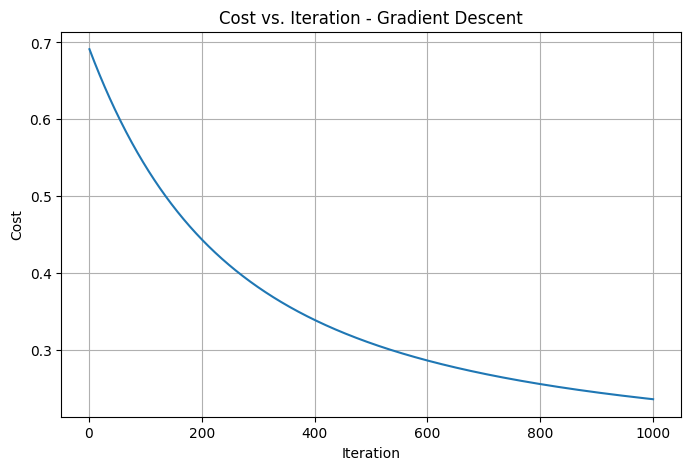


========== SAMPLE PREDICTED PROBABILITIES ==========
[0.11709618 0.2123679  0.14892861 0.24735045 0.11675131 0.1018843
 0.15231865 0.09008687 0.22251539 0.09003862]

========== SAMPLE PREDICTED CLASSES ==========
[0 0 0 0 0 0 0 0 0 0]

========== ACTUAL VS PREDICTED ==========
Actual: 0  Predicted: 0  Probability: 0.1171
Actual: 0  Predicted: 0  Probability: 0.2124
Actual: 0  Predicted: 0  Probability: 0.1489
Actual: 0  Predicted: 0  Probability: 0.2474
Actual: 0  Predicted: 0  Probability: 0.1168
Actual: 0  Predicted: 0  Probability: 0.1019
Actual: 0  Predicted: 0  Probability: 0.1523
Actual: 0  Predicted: 0  Probability: 0.0901
Actual: 0  Predicted: 0  Probability: 0.2225
Actual: 0  Predicted: 0  Probability: 0.09

========== TASK 7 COMPLETED ==========
Logistic Regression implemented successfully using NumPy.
Gradient Descent training completed.


In [ ]:
# ============================================================
# TASK 7: LOGISTIC REGRESSION USING GRADIENT DESCENT
# Credit Card Fraud Detection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Convert training data to NumPy arrays
# ------------------------------------------------------------

X_train_np = np.asarray(X_train, dtype=float)
y_train_np = np.asarray(y_train, dtype=float)

print("Training data shape:", X_train_np.shape)
print("Training target shape:", y_train_np.shape)


# ------------------------------------------------------------
# STEP 2: Define Sigmoid Function
# ------------------------------------------------------------

def sigmoid(z):
    # Prevent numerical overflow
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


# ------------------------------------------------------------
# STEP 3: Define Cost Function
# ------------------------------------------------------------

def compute_cost(X, y, w, b):

    m = len(y)

    # Calculate z
    z = np.dot(X, w) + b

    # Calculate predicted probability
    y_hat = sigmoid(z)

    # Prevent log(0)
    epsilon = 1e-15

    y_hat = np.clip(
        y_hat,
        epsilon,
        1 - epsilon
    )

    # Binary Cross-Entropy Cost
    cost = -(1 / m) * np.sum(
        y * np.log(y_hat)
        +
        (1 - y) * np.log(1 - y_hat)
    )

    return cost


# ------------------------------------------------------------
# STEP 4: Define Gradient Descent Function
# ------------------------------------------------------------

def gradient_descent(X, y, learning_rate, iterations):

    m = X.shape[0]
    n = X.shape[1]

    # Initialize weights and bias
    w = np.zeros(n)
    b = 0.0

    # Store cost values
    cost_history = []

    # --------------------------------------------------------
    # Gradient Descent Loop
    # --------------------------------------------------------

    for i in range(iterations):

        # --------------------------------------------
        # Calculate predictions
        # --------------------------------------------

        z = np.dot(X, w) + b

        y_hat = sigmoid(z)

        # --------------------------------------------
        # Calculate gradients
        # --------------------------------------------

        dw = (1 / m) * np.dot(
            X.T,
            (y_hat - y)
        )

        db = (1 / m) * np.sum(
            y_hat - y
        )

        # --------------------------------------------
        # Update weights
        # --------------------------------------------

        w = w - learning_rate * dw

        # --------------------------------------------
        # Update bias
        # --------------------------------------------

        b = b - learning_rate * db

        # --------------------------------------------
        # Calculate cost
        # --------------------------------------------

        cost = compute_cost(
            X,
            y,
            w,
            b
        )

        cost_history.append(cost)

        # Print cost every 100 iterations
        if i % 100 == 0:
            print(
                "Iteration:",
                i,
                "Cost:",
                cost
            )

    return w, b, cost_history


# ------------------------------------------------------------
# STEP 5: Set Hyperparameters
# ------------------------------------------------------------

learning_rate = 0.01
iterations = 1000

print("\n========== HYPERPARAMETERS ==========")

print("Learning Rate:", learning_rate)
print("Number of Iterations:", iterations)


# ------------------------------------------------------------
# STEP 6: Train Logistic Regression Model
# ------------------------------------------------------------

print("\n========== TRAINING MODEL ==========")

w, b, cost_history = gradient_descent(
    X_train_np,
    y_train_np,
    learning_rate,
    iterations
)


# ------------------------------------------------------------
# STEP 7: Display final parameters
# ------------------------------------------------------------

print("\n========== FINAL MODEL PARAMETERS ==========")

print("Final weights:")
print(w)

print("\nFinal bias:")
print(b)


# ------------------------------------------------------------
# STEP 8: Display initial and final cost
# ------------------------------------------------------------

print("\n========== COST INFORMATION ==========")

print("Initial Cost:", cost_history[0])

print("Final Cost:", cost_history[-1])


# ------------------------------------------------------------
# STEP 9: Plot Cost vs Iteration
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    cost_history
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs. Iteration - Gradient Descent")

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# STEP 10: Define prediction function
# ------------------------------------------------------------

def predict_probability(X, w, b):

    z = np.dot(X, w) + b

    return sigmoid(z)


# ------------------------------------------------------------
# STEP 11: Generate training predictions
# ------------------------------------------------------------

train_probabilities = predict_probability(
    X_train_np,
    w,
    b
)

print("\n========== SAMPLE PREDICTED PROBABILITIES ==========")

print(train_probabilities[:10])


# ------------------------------------------------------------
# STEP 12: Convert probabilities into classes
# ------------------------------------------------------------

train_predictions = (
    train_probabilities >= 0.5
).astype(int)

print("\n========== SAMPLE PREDICTED CLASSES ==========")

print(train_predictions[:10])


# ------------------------------------------------------------
# STEP 13: Compare actual and predicted values
# ------------------------------------------------------------

print("\n========== ACTUAL VS PREDICTED ==========")

for i in range(10):
    print(
        "Actual:",
        int(y_train_np[i]),
        " Predicted:",
        train_predictions[i],
        " Probability:",
        round(train_probabilities[i], 4)
    )


print("\n========== TASK 7 COMPLETED ==========")
print("Logistic Regression implemented successfully using NumPy.")
print("Gradient Descent training completed.")

## Task 8: Generate Predictions and Evaluate the Confusion Matrix

Use the trained Logistic Regression model to calculate the **fraud probabilities** for the validation and test datasets.

The predicted probability is calculated using:

$$
\hat{y} = \sigma(Xw+b)
$$

Convert the predicted probabilities into class labels using a threshold of **0.5**:

$$
\hat{y}_{class} =
\begin{cases}
1, & \text{if } \hat{y} \geq 0.5 \
0, & \text{if } \hat{y} < 0.5
\end{cases}
$$

Construct the **Confusion Matrix** and identify the following:

* **True Positive (TP):** Fraudulent transactions correctly classified as fraudulent.
* **True Negative (TN):** Legitimate transactions correctly classified as legitimate.
* **False Positive (FP):** Legitimate transactions incorrectly classified as fraudulent.
* **False Negative (FN):** Fraudulent transactions incorrectly classified as legitimate.

The confusion matrix can be represented as:

$$
\text{Confusion Matrix} =
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

Explain the meaning of each result in the context of **credit card fraud detection**.

The objective of this task is to evaluate the classification results of the Logistic Regression model and understand the different types of prediction errors, with particular attention to **False Negatives**, which represent fraudulent transactions that are not detected.


Validation data shape: (200000, 7)
Validation target shape: (200000,)

Test data shape: (200000, 7)
Test target shape: (200000,)

========== VALIDATION FRAUD PROBABILITIES ==========
First 10 validation probabilities:
[0.1592 0.1168 0.0824 0.1275 0.1352 0.1419 0.0948 0.2289 0.076  0.1519]

========== TEST FRAUD PROBABILITIES ==========
First 10 test probabilities:
[0.0809 0.1399 0.3588 0.1194 0.1775 0.1528 0.1287 0.0946 0.2418 0.1547]

========== PREDICTED CLASS LABELS ==========
First 10 validation predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 test predictions:
[0 0 0 0 0 0 0 0 0 0]

========== VALIDATION CONFUSION MATRIX ==========
[[181251   1268]
 [ 13633   3848]]

Validation Set:
True Negative (TN): 181251
False Positive (FP): 1268
False Negative (FN): 13633
True Positive (TP): 3848

========== TEST CONFUSION MATRIX ==========
[[181233   1287]
 [ 13803   3677]]

Test Set:
True Negative (TN): 181233
False Positive (FP): 1287
False Negative (FN): 13803
True Positive (TP): 3677


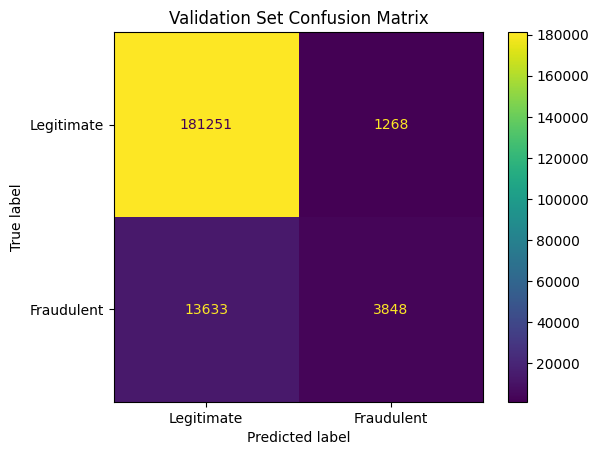

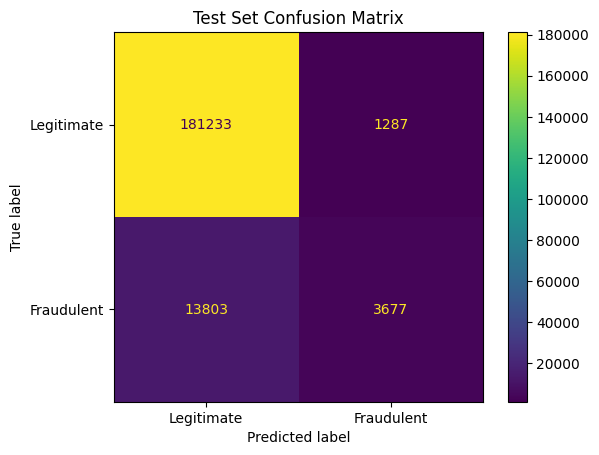


========== ACTUAL VS PREDICTED - TEST SET ==========
Actual: 0 | Probability: 0.0809 | Predicted: 0
Actual: 0 | Probability: 0.1399 | Predicted: 0
Actual: 1 | Probability: 0.3588 | Predicted: 0
Actual: 0 | Probability: 0.1194 | Predicted: 0
Actual: 0 | Probability: 0.1775 | Predicted: 0
Actual: 0 | Probability: 0.1528 | Predicted: 0
Actual: 0 | Probability: 0.1287 | Predicted: 0
Actual: 0 | Probability: 0.0946 | Predicted: 0
Actual: 0 | Probability: 0.2418 | Predicted: 0
Actual: 0 | Probability: 0.1547 | Predicted: 0

========== TASK 8 SUMMARY ==========
Threshold used: 0.5

Validation Set:
TN = 181251
FP = 1268
FN = 13633
TP = 3848

Test Set:
TN = 181233
FP = 1287
FN = 13803
TP = 3677


In [ ]:
# ============================================================
# TASK 8: GENERATE PREDICTIONS AND EVALUATE CONFUSION MATRIX
# Credit Card Fraud Detection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# STEP 1: Convert validation and test data to NumPy arrays
# ------------------------------------------------------------

X_val_np = np.asarray(X_val, dtype=float)
y_val_np = np.asarray(y_val, dtype=int)

X_test_np = np.asarray(X_test, dtype=float)
y_test_np = np.asarray(y_test, dtype=int)

print("Validation data shape:", X_val_np.shape)
print("Validation target shape:", y_val_np.shape)

print("\nTest data shape:", X_test_np.shape)
print("Test target shape:", y_test_np.shape)


# ------------------------------------------------------------
# STEP 2: Define sigmoid function
# ------------------------------------------------------------

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# ------------------------------------------------------------
# STEP 3: Generate fraud probabilities
# ------------------------------------------------------------

def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)


# Validation probabilities
val_probabilities = predict_probability(
    X_val_np,
    w,
    b
)

# Test probabilities
test_probabilities = predict_probability(
    X_test_np,
    w,
    b
)


# ------------------------------------------------------------
# STEP 4: Display sample fraud probabilities
# ------------------------------------------------------------

print("\n========== VALIDATION FRAUD PROBABILITIES ==========")

print("First 10 validation probabilities:")
print(np.round(val_probabilities[:10], 4))


print("\n========== TEST FRAUD PROBABILITIES ==========")

print("First 10 test probabilities:")
print(np.round(test_probabilities[:10], 4))


# ------------------------------------------------------------
# STEP 5: Convert probabilities into class labels
# Threshold = 0.5
# ------------------------------------------------------------

threshold = 0.5

y_val_pred = (
    val_probabilities >= threshold
).astype(int)

y_test_pred = (
    test_probabilities >= threshold
).astype(int)


print("\n========== PREDICTED CLASS LABELS ==========")

print("First 10 validation predictions:")
print(y_val_pred[:10])

print("\nFirst 10 test predictions:")
print(y_test_pred[:10])


# ------------------------------------------------------------
# STEP 6: Create confusion matrix - Validation Set
# ------------------------------------------------------------

cm_val = confusion_matrix(
    y_val_np,
    y_val_pred
)

print("\n========== VALIDATION CONFUSION MATRIX ==========")

print(cm_val)


# ------------------------------------------------------------
# STEP 7: Extract TP, TN, FP, FN - Validation
# ------------------------------------------------------------

TN_val = cm_val[0, 0]
FP_val = cm_val[0, 1]
FN_val = cm_val[1, 0]
TP_val = cm_val[1, 1]

print("\nValidation Set:")
print("True Negative (TN):", TN_val)
print("False Positive (FP):", FP_val)
print("False Negative (FN):", FN_val)
print("True Positive (TP):", TP_val)


# ------------------------------------------------------------
# STEP 8: Create confusion matrix - Test Set
# ------------------------------------------------------------

cm_test = confusion_matrix(
    y_test_np,
    y_test_pred
)

print("\n========== TEST CONFUSION MATRIX ==========")

print(cm_test)


# ------------------------------------------------------------
# STEP 9: Extract TP, TN, FP, FN - Test
# ------------------------------------------------------------

TN_test = cm_test[0, 0]
FP_test = cm_test[0, 1]
FN_test = cm_test[1, 0]
TP_test = cm_test[1, 1]

print("\nTest Set:")
print("True Negative (TN):", TN_test)
print("False Positive (FP):", FP_test)
print("False Negative (FN):", FN_test)
print("True Positive (TP):", TP_test)


# ------------------------------------------------------------
# STEP 10: Plot Validation Confusion Matrix
# ------------------------------------------------------------

disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Legitimate", "Fraudulent"]
)

disp_val.plot()

plt.title("Validation Set Confusion Matrix")
plt.show()


# ------------------------------------------------------------
# STEP 11: Plot Test Confusion Matrix
# ------------------------------------------------------------

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Legitimate", "Fraudulent"]
)

disp_test.plot()

plt.title("Test Set Confusion Matrix")
plt.show()


# ------------------------------------------------------------
# STEP 12: Display sample actual vs predicted results
# ------------------------------------------------------------

print("\n========== ACTUAL VS PREDICTED - TEST SET ==========")

for i in range(min(10, len(y_test_np))):
    print(
        "Actual:",
        y_test_np[i],
        "| Probability:",
        round(test_probabilities[i], 4),
        "| Predicted:",
        y_test_pred[i]
    )


# ------------------------------------------------------------
# STEP 13: Final summary
# ------------------------------------------------------------

print("\n========== TASK 8 SUMMARY ==========")

print("Threshold used:", threshold)

print("\nValidation Set:")
print("TN =", TN_val)
print("FP =", FP_val)
print("FN =", FN_val)
print("TP =", TP_val)

print("\nTest Set:")
print("TN =", TN_test)
print("FP =", FP_test)
print("FN =", FN_test)
print("TP =", TP_test)

## Task 9: Calculate Precision, Recall and F1-Score

Calculate the following performance metrics for the Logistic Regression model:

### Precision

Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent.

$$
\text{Precision} =
\frac{TP}{TP+FP}
$$

### Recall

Recall measures the proportion of actual fraudulent transactions that are correctly identified by the model.

$$
\text{Recall} =
\frac{TP}{TP+FN}
$$

### F1-Score

The F1-Score is the harmonic mean of Precision and Recall.

$$
F1\text{-Score} =
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision}+\text{Recall}}
$$

### Accuracy

Calculate accuracy for comparison:

$$
\text{Accuracy} =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Display the calculated **Accuracy, Precision, Recall, and F1-Score**.

Explain why **Recall is more important than accuracy** in many fraud detection applications. A False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. Therefore, a model with high accuracy but low Recall may fail to detect a significant number of fraudulent transactions.

The objective of this task is to evaluate the Logistic Regression model using appropriate classification metrics and understand the importance of Recall in credit card fraud detection.


In [ ]:
# ============================================================
# TASK 9: CALCULATE PRECISION, RECALL, F1-SCORE AND ACCURACY
# Credit Card Fraud Detection
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# STEP 1: Calculate metrics for Validation Set
# ------------------------------------------------------------

validation_accuracy = accuracy_score(
    y_val_np,
    y_val_pred
)

validation_precision = precision_score(
    y_val_np,
    y_val_pred,
    zero_division=0
)

validation_recall = recall_score(
    y_val_np,
    y_val_pred,
    zero_division=0
)

validation_f1 = f1_score(
    y_val_np,
    y_val_pred,
    zero_division=0
)


# ------------------------------------------------------------
# STEP 2: Calculate metrics for Test Set
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test_np,
    y_test_pred
)

test_precision = precision_score(
    y_test_np,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_np,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_np,
    y_test_pred,
    zero_division=0
)


# ------------------------------------------------------------
# STEP 3: Display Validation Metrics
# ------------------------------------------------------------

print("================================================")
print("       VALIDATION SET PERFORMANCE")
print("================================================")

print("Accuracy  :", round(validation_accuracy, 4))
print("Precision :", round(validation_precision, 4))
print("Recall    :", round(validation_recall, 4))
print("F1-Score  :", round(validation_f1, 4))


# ------------------------------------------------------------
# STEP 4: Display Test Metrics
# ------------------------------------------------------------

print("\n================================================")
print("           TEST SET PERFORMANCE")
print("================================================")

print("Accuracy  :", round(test_accuracy, 4))
print("Precision :", round(test_precision, 4))
print("Recall    :", round(test_recall, 4))
print("F1-Score  :", round(test_f1, 4))


# ------------------------------------------------------------
# STEP 5: Calculate metrics manually using
#         Confusion Matrix values
# ------------------------------------------------------------

# Test-set confusion matrix values were calculated in Task 8

TN = TN_test
FP = FP_test
FN = FN_test
TP = TP_test

# Accuracy
manual_accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision
if (TP + FP) != 0:
    manual_precision = TP / (TP + FP)
else:
    manual_precision = 0

# Recall
if (TP + FN) != 0:
    manual_recall = TP / (TP + FN)
else:
    manual_recall = 0

# F1-Score
if (manual_precision + manual_recall) != 0:
    manual_f1 = (
        2 * manual_precision * manual_recall
        / (manual_precision + manual_recall)
    )
else:
    manual_f1 = 0


# ------------------------------------------------------------
# STEP 6: Display manually calculated metrics
# ------------------------------------------------------------

print("\n================================================")
print("       MANUAL TEST SET CALCULATIONS")
print("================================================")

print("True Negative  (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive  (TP):", TP)

print("\nManual Accuracy  :", round(manual_accuracy, 4))
print("Manual Precision :", round(manual_precision, 4))
print("Manual Recall    :", round(manual_recall, 4))
print("Manual F1-Score  :", round(manual_f1, 4))


# ------------------------------------------------------------
# STEP 7: Convert metrics to percentage
# ------------------------------------------------------------

print("\n================================================")
print("       TEST METRICS IN PERCENTAGE")
print("================================================")

print("Accuracy  :", round(test_accuracy * 100, 2), "%")
print("Precision :", round(test_precision * 100, 2), "%")
print("Recall    :", round(test_recall * 100, 2), "%")
print("F1-Score  :", round(test_f1 * 100, 2), "%")


# ------------------------------------------------------------
# STEP 8: Final interpretation
# ------------------------------------------------------------

print("\n================================================")
print("               INTERPRETATION")
print("================================================")

print("Accuracy : Overall proportion of correctly classified transactions.")

print("Precision: Among transactions predicted as fraud,")
print("           the proportion that were actually fraudulent.")

print("Recall   : Among actual fraudulent transactions,")
print("           the proportion correctly detected by the model.")

print("F1-Score : Harmonic mean of Precision and Recall.")

print("\nIn fraud detection, Recall is especially important")
print("because False Negatives represent fraudulent transactions")
print("that the model failed to detect.")

print("\nA model can have very high Accuracy because legitimate")
print("transactions are much more numerous than fraudulent ones.")
print("However, it may still have poor Recall and miss many fraud cases.")

print("\n========== TASK 9 COMPLETED ==========")

       VALIDATION SET PERFORMANCE
Accuracy  : 0.9255
Precision : 0.7522
Recall    : 0.2201
F1-Score  : 0.3406

           TEST SET PERFORMANCE
Accuracy  : 0.9245
Precision : 0.7407
Recall    : 0.2104
F1-Score  : 0.3277

       MANUAL TEST SET CALCULATIONS
True Negative  (TN): 181233
False Positive (FP): 1287
False Negative (FN): 13803
True Positive  (TP): 3677

Manual Accuracy  : 0.9246
Manual Precision : 0.7407
Manual Recall    : 0.2104
Manual F1-Score  : 0.3277

       TEST METRICS IN PERCENTAGE
Accuracy  : 92.45 %
Precision : 74.07 %
Recall    : 21.04 %
F1-Score  : 32.77 %

               INTERPRETATION
Accuracy : Overall proportion of correctly classified transactions.
Precision: Among transactions predicted as fraud,
           the proportion that were actually fraudulent.
Recall   : Among actual fraudulent transactions,
           the proportion correctly detected by the model.
F1-Score : Harmonic mean of Precision and Recall.

In fraud detection, Recall is especially important
b

## Task 10: Plot ROC Curve, Calculate AUC and Interpret Results

Calculate the **False Positive Rate (FPR)** and **True Positive Rate (TPR)** for different classification thresholds.

The False Positive Rate is calculated as:

$$
FPR =
\frac{FP}{FP+TN}
$$

The True Positive Rate is equivalent to Recall and is calculated as:

$$
TPR =
\frac{TP}{TP+FN}
$$

Plot the **Receiver Operating Characteristic (ROC) Curve)** by plotting FPR on the (x)-axis and TPR on the (y)-axis for different classification thresholds.

Calculate the **Area Under the ROC Curve (AUC)** to measure the ability of the Logistic Regression model to distinguish between fraudulent and legitimate transactions.

Prepare a final performance summary containing:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

Interpret the model performance and discuss the trade-off between **False Positives and False Negatives**.

A higher ROC-AUC value indicates better ability of the model to distinguish between fraudulent and legitimate transactions.

Explain whether the trained Logistic Regression model is suitable as a **baseline model for credit card fraud detection**.

The objective of this task is to evaluate the overall classification performance of the Logistic Regression model using the ROC Curve and AUC and to understand the trade-off between detecting fraudulent transactions and incorrectly flagging legitimate transactions.


========== SAMPLE TEST FRAUD PROBABILITIES ==========
[0.0809 0.1399 0.3588 0.1194 0.1775 0.1528 0.1287 0.0946 0.2418 0.1547]

========== ROC VALUES ==========
Number of thresholds: 13396

First 10 FPR values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 TPR values:
[0.     0.     0.0002 0.0002 0.0003 0.0003 0.0003 0.0003 0.0004 0.0004]

First 10 thresholds:
[inf  1.  1.  1.  1.  1.  1.  1.  1.  1.]

========== ROC-AUC ==========
ROC-AUC: 0.9746
ROC-AUC (%): 97.46 %


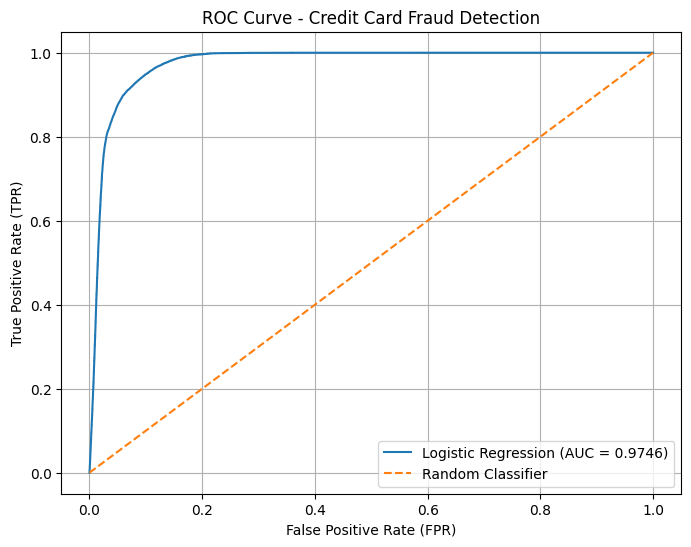


========== CONFUSION MATRIX ==========
[[181233   1287]
 [ 13803   3677]]

True Negative (TN): 181233
False Positive (FP): 1287
False Negative (FN): 13803
True Positive (TP): 3677

        FINAL MODEL PERFORMANCE SUMMARY
Accuracy  : 0.9245 ( 92.45 %)
Precision : 0.7407 ( 74.07 %)
Recall    : 0.2104 ( 21.04 %)
F1-Score  : 0.3277 ( 32.77 %)
ROC-AUC   : 0.9746 ( 97.46 %)

========== CONFUSION MATRIX DETAILS ==========
                 Predicted
                 Legit   Fraud
Actual Legit     181233       1287
Actual Fraud     13803       3677

========== PERFORMANCE AT THRESHOLD 0.5 ==========
False Positive Rate (FPR): 0.0071
True Positive Rate (TPR): 0.2104

              MODEL INTERPRETATION
The model has excellent discrimination ability.

Recall indicates how many actual fraudulent
transactions were successfully detected.
Precision indicates how many transactions
predicted as fraud were actually fraudulent.
FPR indicates how many legitimate transactions
were incorrectly flagged as fr

In [ ]:
# ============================================================
# TASK 10: ROC CURVE, AUC AND FINAL PERFORMANCE SUMMARY
# Credit Card Fraud Detection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# STEP 1: Generate probabilities for the TEST SET
# ------------------------------------------------------------

# Probability that each transaction is fraudulent
test_probabilities = predict_probability(
    X_test_np,
    w,
    b
)

print("========== SAMPLE TEST FRAUD PROBABILITIES ==========")
print(np.round(test_probabilities[:10], 4))


# ------------------------------------------------------------
# STEP 2: Calculate FPR and TPR for different thresholds
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test_np,
    test_probabilities
)

print("\n========== ROC VALUES ==========")

print("Number of thresholds:", len(thresholds))

print("\nFirst 10 FPR values:")
print(np.round(fpr[:10], 4))

print("\nFirst 10 TPR values:")
print(np.round(tpr[:10], 4))

print("\nFirst 10 thresholds:")
print(np.round(thresholds[:10], 4))


# ------------------------------------------------------------
# STEP 3: Calculate ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_test_np,
    test_probabilities
)

print("\n========== ROC-AUC ==========")
print("ROC-AUC:", round(roc_auc, 4))
print("ROC-AUC (%):", round(roc_auc * 100, 2), "%")


# ------------------------------------------------------------
# STEP 4: Plot ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression (AUC = {:.4f})".format(roc_auc)
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Credit Card Fraud Detection")

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# STEP 5: Calculate final predictions using threshold = 0.5
# ------------------------------------------------------------

threshold = 0.5

y_test_pred = (
    test_probabilities >= threshold
).astype(int)


# ------------------------------------------------------------
# STEP 6: Calculate confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test_np,
    y_test_pred
)

TN, FP, FN, TP = cm.ravel()

print("\n========== CONFUSION MATRIX ==========")

print(cm)

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)


# ------------------------------------------------------------
# STEP 7: Calculate final performance metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test_np,
    y_test_pred
)

precision = precision_score(
    y_test_np,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test_np,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_np,
    y_test_pred,
    zero_division=0
)


# ------------------------------------------------------------
# STEP 8: Display final performance summary
# ------------------------------------------------------------

print("\n================================================")
print("        FINAL MODEL PERFORMANCE SUMMARY")
print("================================================")

print("Accuracy  :", round(accuracy, 4),
      "(", round(accuracy * 100, 2), "%)")

print("Precision :", round(precision, 4),
      "(", round(precision * 100, 2), "%)")

print("Recall    :", round(recall, 4),
      "(", round(recall * 100, 2), "%)")

print("F1-Score  :", round(f1, 4),
      "(", round(f1 * 100, 2), "%)")

print("ROC-AUC   :", round(roc_auc, 4),
      "(", round(roc_auc * 100, 2), "%)")


# ------------------------------------------------------------
# STEP 9: Display confusion matrix in readable format
# ------------------------------------------------------------

print("\n========== CONFUSION MATRIX DETAILS ==========")

print("                 Predicted")
print("                 Legit   Fraud")
print("Actual Legit    ", TN, "     ", FP)
print("Actual Fraud    ", FN, "     ", TP)


# ------------------------------------------------------------
# STEP 10: Calculate FPR and TPR at threshold 0.5
# ------------------------------------------------------------

if (FP + TN) != 0:
    fpr_05 = FP / (FP + TN)
else:
    fpr_05 = 0

if (TP + FN) != 0:
    tpr_05 = TP / (TP + FN)
else:
    tpr_05 = 0

print("\n========== PERFORMANCE AT THRESHOLD 0.5 ==========")

print("False Positive Rate (FPR):",
      round(fpr_05, 4))

print("True Positive Rate (TPR):",
      round(tpr_05, 4))


# ------------------------------------------------------------
# STEP 11: Final interpretation
# ------------------------------------------------------------

print("\n================================================")
print("              MODEL INTERPRETATION")
print("================================================")

if roc_auc >= 0.90:
    print("The model has excellent discrimination ability.")
elif roc_auc >= 0.80:
    print("The model has good discrimination ability.")
elif roc_auc >= 0.70:
    print("The model has acceptable discrimination ability.")
else:
    print("The model has limited discrimination ability.")

print("\nRecall indicates how many actual fraudulent")
print("transactions were successfully detected.")

print("Precision indicates how many transactions")
print("predicted as fraud were actually fraudulent.")

print("FPR indicates how many legitimate transactions")
print("were incorrectly flagged as fraudulent.")

print("\nA higher Recall can help detect more fraud,")
print("but it may also increase False Positives.")

print("A lower False Positive Rate reduces inconvenience")
print("to legitimate customers, but may result in more")
print("fraudulent transactions being missed.")

print("\nLogistic Regression can be used as a baseline")
print("model for credit card fraud detection because it")
print("is simple, interpretable, and provides probabilities.")

print("\n========== TASK 10 COMPLETED ==========")

## Conclusion

The experiment successfully demonstrated the implementation of **Logistic Regression for credit card fraud detection**. The complete workflow included data preprocessing, exploratory data analysis, feature scaling, class-imbalance handling, dataset splitting, Sigmoid Function implementation, Binary Cross-Entropy Cost Function, and Gradient Descent optimization.

The trained Logistic Regression model was evaluated using the **Confusion Matrix, Accuracy, Precision, Recall, F1-Score, ROC Curve, and ROC-AUC**. The results demonstrate that accuracy alone is not an adequate performance measure for highly imbalanced fraud detection datasets.

Particular importance was given to **Recall**, because a False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. A suitable fraud detection model should therefore achieve satisfactory Recall while maintaining an acceptable level of False Positives.

Overall, Logistic Regression provides an **interpretable and effective baseline model** for credit card fraud detection. The experiment also demonstrates the importance of selecting appropriate evaluation metrics and handling class imbalance when developing machine learning models for fraud detection.
